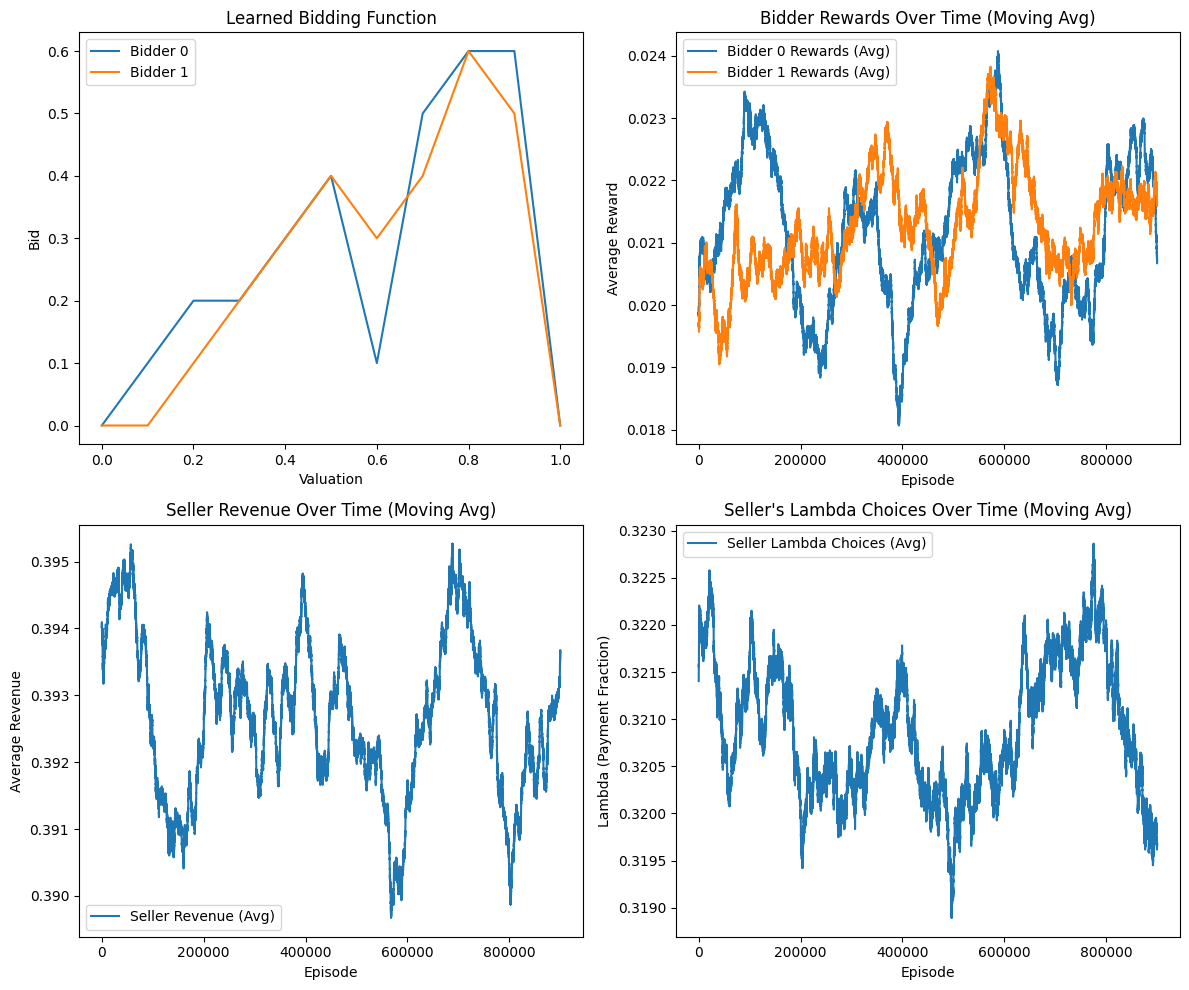

In [33]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Define parameters
alpha = 0.1  # learning rate
num_episodes = 1000000  # number of episodes
num_bids = 11  # number of discrete bid steps (0 to 1 in 0.1 increments)
bid_values = [0.1 * i for i in range(num_bids)]  # Discretized bid values
avg_window = 100000  # Window for calculating moving averages
epsilon_start = 0.99  # Starting epsilon for exploration
epsilon_end = 0.2  # Ending epsilon
epsilon_decay = 1.0  # Epsilon decay rate
K = 1000  # Length of each exploration phase

# Epsilon-greedy exploration function
def epsilon_greedy(q_values, epsilon):
    if random.uniform(0, 1) < epsilon:
        return random.choice(range(len(q_values)))
    else:
        return np.argmax(q_values)

# Bidder class for Q-learning with updated rewards
class QLearningBidder:
    def __init__(self):
        self.q_table = np.ones((num_bids, num_bids))  # State (valuation), action (bid)
        self.rewards = []

    def choose_bid(self, valuation_index, epsilon):
        return epsilon_greedy(self.q_table[valuation_index], epsilon)  # Epsilon-greedy exploration

    def update_q_table(self, state, action, reward):
        self.q_table[state][action] += alpha * (reward - self.q_table[state][action])
        self.rewards.append(reward)

# Seller class for Q-learning with updated rewards
class QLearningSeller:
    def __init__(self):
        self.q_table = np.ones((num_bids, num_bids, num_bids))  # Seller's Q-table with no state
        self.lambdas = []
        self.rewards = []

    def choose_lambda(self, b0_discrete, b1_discrete, epsilon):
        min_bid, max_bid = min(b0_discrete, b1_discrete), max(b0_discrete, b1_discrete)
        q_values = self.q_table[min_bid, max_bid]  # Array of possible actions (fractions between bids)
        return bid_values[epsilon_greedy(q_values, epsilon)]

    def update_q_table(self, b0_discrete, b1_discrete, revenue):
        min_bid, max_bid = min(b0_discrete, b1_discrete), max(b0_discrete, b1_discrete)
        action = int(revenue * 10)  # Mapping revenue back to discrete action
        self.q_table[min_bid, max_bid, action] += alpha * (revenue - self.q_table[min_bid, max_bid, action])
        self.rewards.append(revenue)

# Function to calculate bidder reward
def get_bidder_reward(bid, other_bid, valuation, seller_fraction):
    if bid > other_bid:
        return valuation - bid + 0.02  # Reward for winning + small bonus
    elif bid == other_bid:
        return valuation - bid if random.choice([True, False]) else 0  # Tie break
    else:
        return 0  # Loss, no reward

# Function to calculate seller revenue based on lambda
def get_seller_revenue(b0, b1, lambda_val):
    return lambda_val * b1 + (1 - lambda_val) * b0

# Function to calculate moving average
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Training loop with alternating exploration phases every K episodes
bidder0 = QLearningBidder()
bidder1 = QLearningBidder()
seller = QLearningSeller()

epsilon = epsilon_start

for episode in range(num_episodes):
    # Randomly draw valuations for two bidders
    v0, v1 = np.random.uniform(0, 1, 2)
    
    # Discretize the valuations
    v0_discrete = int(v0 * 10)
    v1_discrete = int(v1 * 10)

    if (episode // K) % 2 == 0:  # Bidder exploration phase
        # Bidders explore, seller does not
        b0_discrete = bidder0.choose_bid(v0_discrete, epsilon)
        b1_discrete = bidder1.choose_bid(v1_discrete, epsilon)
        seller_lambda = seller.choose_lambda(b0_discrete, b1_discrete, 0.1)  # Minimal seller exploration
    else:  # Seller exploration phase
        # Seller explores, bidders do not
        b0_discrete = bidder0.choose_bid(v0_discrete, 0.1)  # Minimal bidder exploration
        b1_discrete = bidder1.choose_bid(v1_discrete, 0.1)
        seller_lambda = seller.choose_lambda(b0_discrete, b1_discrete, epsilon)

    # Decay epsilon
    epsilon = max(epsilon_end, epsilon * epsilon_decay)

    # Get the actual bid values
    b0 = bid_values[b0_discrete]
    b1 = bid_values[b1_discrete]

    # Calculate rewards for both bidders
    reward_b0 = get_bidder_reward(b0, b1, v0, seller_lambda)
    reward_b1 = get_bidder_reward(b1, b0, v1, seller_lambda)
    
    # Calculate seller's revenue
    seller_revenue = get_seller_revenue(b0, b1, seller_lambda)
    
    # Update Q-tables for both bidders and the seller
    bidder0.update_q_table(v0_discrete, b0_discrete, reward_b0)
    bidder1.update_q_table(v1_discrete, b1_discrete, reward_b1)
    seller.update_q_table(b0_discrete, b1_discrete, seller_revenue)
    
    # Store seller's lambda choice
    seller.lambdas.append(seller_lambda)

# Plot all graphs in a grid layout
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Plot the learned bidding function b = f(v) for both bidders
axs[0, 0].plot(bid_values, [np.argmax(bidder0.q_table[i]) / 10 for i in range(num_bids)], label="Bidder 0")
axs[0, 0].plot(bid_values, [np.argmax(bidder1.q_table[i]) / 10 for i in range(num_bids)], label="Bidder 1")
axs[0, 0].set_xlabel("Valuation")
axs[0, 0].set_ylabel("Bid")
axs[0, 0].set_title("Learned Bidding Function")
axs[0, 0].legend()

# Plot the historical rewards for bidders (moving average over 1000 rounds)
axs[0, 1].plot(moving_average(bidder0.rewards, avg_window), label="Bidder 0 Rewards (Avg)")
axs[0, 1].plot(moving_average(bidder1.rewards, avg_window), label="Bidder 1 Rewards (Avg)")
axs[0, 1].set_xlabel("Episode")
axs[0, 1].set_ylabel("Average Reward")
axs[0, 1].set_title("Bidder Rewards Over Time (Moving Avg)")
axs[0, 1].legend()

# Plot the seller's historical rewards (moving average over 1000 rounds)
axs[1, 0].plot(moving_average(seller.rewards, avg_window), label="Seller Revenue (Avg)")
axs[1, 0].set_xlabel("Episode")
axs[1, 0].set_ylabel("Average Revenue")
axs[1, 0].set_title("Seller Revenue Over Time (Moving Avg)")
axs[1, 0].legend()

# Plot the seller's lambda choices over time (moving average over 1000 rounds)
axs[1, 1].plot(moving_average(seller.lambdas, avg_window), label="Seller Lambda Choices (Avg)")
axs[1, 1].set_xlabel("Episode")
axs[1, 1].set_ylabel("Lambda (Payment Fraction)")
axs[1, 1].set_title("Seller's Lambda Choices Over Time (Moving Avg)")
axs[1, 1].legend()

plt.tight_layout()
plt.show()


In [38]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Define the policy network for continuous actions (bids)
class PolicyNetwork(nn.Module):
    def __init__(self):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(1, 128)  # Input is valuation
        self.fc2 = nn.Linear(128, 128)
        self.fc_mu = nn.Linear(128, 1)  # Output is bid (mean of normal distribution)
        self.fc_std = nn.Linear(128, 1)  # Output is standard deviation of normal distribution

    def forward(self, x):
        x = torch.leaky_relu(self.fc1(x))
        x = torch.leaky_relu(self.fc2(x))
        mu = torch.tanh(self.fc_mu(x)) * 0.5 + 0.5  # Bid is between 0 and 1
        std = torch.nn.functional.softplus(self.fc_std(x)) + 1e-5  # Positive std deviation
        return mu, std

# Define the agent
class Agent:
    def __init__(self):
        self.policy_net = PolicyNetwork()
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=0.01)
        self.gamma = 0.99  # Discount factor
        self.log_probs = []
        self.rewards = []

    # Get an action (bid) based on valuation using the policy network
    def get_action(self, valuation):
        mu, std = self.policy_net(torch.tensor([valuation], dtype=torch.float32))
        std = torch.clamp(std, min=1e-4)  # Ensure std doesn't get too small
        dist = torch.distributions.Normal(mu, std)
        action = dist.sample()  # Sample bid from distribution
        log_prob = dist.log_prob(action)
        self.log_probs.append(log_prob)
        return torch.clamp(action, 0.0, 1.0).item()  # Ensure the bid stays between 0 and 1

    # Store rewards obtained in each step
    def store_reward(self, reward):
        self.rewards.append(reward)

    # Perform policy gradient update
    def update_policy(self):
        discounted_rewards = []
        cumulative_reward = 0
        for reward in reversed(self.rewards):
            cumulative_reward = reward + self.gamma * cumulative_reward
            discounted_rewards.insert(0, cumulative_reward)
        
        discounted_rewards = torch.tensor(discounted_rewards)
        discounted_rewards = (discounted_rewards - discounted_rewards.mean()) / (discounted_rewards.std() + 1e-5)

        policy_loss = []
        for log_prob, reward in zip(self.log_probs, discounted_rewards):
            policy_loss.append(-log_prob * reward)
        
        self.optimizer.zero_grad()
        policy_loss = torch.cat(policy_loss).sum()
        policy_loss.backward()
        self.optimizer.step()

        self.log_probs = []
        self.rewards = []

# Function to calculate the reward for a first-price auction
def get_reward(bid, other_bid, valuation):
    if bid > other_bid:
        return valuation - bid  # Win and pay bid
    elif bid == other_bid:
        return (valuation - bid) / 2  # Tie break
    else:
        return 0  # Lose, no reward

# Set up the environment
num_episodes = 1000
agent0 = Agent()
agent1 = Agent()
all_rewards_0 = []
all_rewards_1 = []

for episode in range(num_episodes):
    # Draw random valuations for both bidders
    v0 = np.random.uniform(0, 1)
    v1 = np.random.uniform(0, 1)

    # Bidders choose their bids
    b0 = agent0.get_action(v0)
    b1 = agent1.get_action(v1)

    # Calculate rewards for both bidders
    reward_0 = get_reward(b0, b1, v0)
    reward_1 = get_reward(b1, b0, v1)

    # Store rewards
    agent0.store_reward(reward_0)
    agent1.store_reward(reward_1)

    # Collect episode rewards for plotting
    all_rewards_0.append(reward_0)
    all_rewards_1.append(reward_1)

    # Update policy after every episode
    agent0.update_policy()
    agent1.update_policy()

# Plot the results
plt.plot(np.convolve(all_rewards_0, np.ones(100) / 100, mode='valid'), label="Bidder 0")
plt.plot(np.convolve(all_rewards_1, np.ones(100) / 100, mode='valid'), label="Bidder 1")
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Bidder Rewards Over Time (First-Price Auction)")
plt.legend()
plt.show()


ValueError: Expected parameter loc (Tensor of shape (1,)) of distribution Normal(loc: tensor([nan], grad_fn=<AddBackward0>), scale: tensor([nan], grad_fn=<ClampBackward1>)) to satisfy the constraint Real(), but found invalid values:
tensor([nan], grad_fn=<AddBackward0>)

Episode:    100	Avg. Return:   0.37
Episode:    200	Avg. Return:   0.38
Episode:    300	Avg. Return:   0.52
Episode:    400	Avg. Return:   0.21
Episode:    500	Avg. Return:   0.24
Episode:    600	Avg. Return:   0.36
Episode:    700	Avg. Return:   0.03
Episode:    800	Avg. Return:   0.51
Episode:    900	Avg. Return:   0.92
Episode:   1000	Avg. Return:   0.91
Episode:   1100	Avg. Return:   0.62
Episode:   1200	Avg. Return:   0.60
Episode:   1300	Avg. Return:   0.19
Episode:   1400	Avg. Return:   0.20
Episode:   1500	Avg. Return:   0.09
Episode:   1600	Avg. Return:   0.15
Episode:   1700	Avg. Return:   0.15
Episode:   1800	Avg. Return:   0.35
Episode:   1900	Avg. Return:   0.61
Episode:   2000	Avg. Return:   0.73
Episode:   2100	Avg. Return:   0.56
Episode:   2200	Avg. Return:   0.48
Episode:   2300	Avg. Return:   0.64
Episode:   2400	Avg. Return:   0.40
Episode:   2500	Avg. Return:   0.31
Episode:   2600	Avg. Return:   0.26
Episode:   2700	Avg. Return:   0.33
Episode:   2800	Avg. Return:

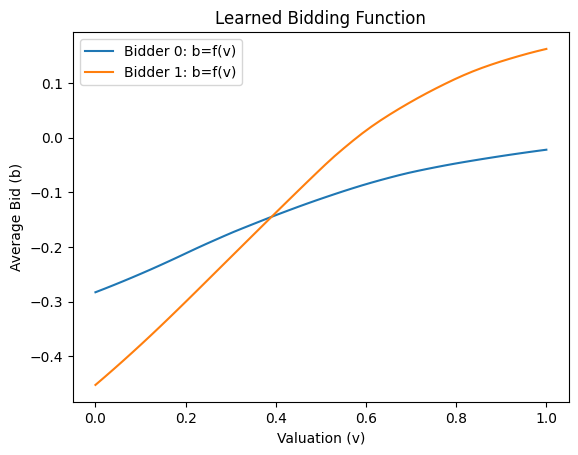

In [43]:
# import dependencies
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
import numpy as np
from collections import deque
import matplotlib.pyplot as plt

# define policy network for continuous action space
class policy_net(nn.Module):
    def __init__(self, nS, nH, nA):  # nS: state space size, nH: n. of neurons in hidden layer, nA: size of action space
        super(policy_net, self).__init__()
        self.h = nn.Linear(nS, nH)
        self.mu = nn.Linear(nH, nA)  # Output mean for continuous action
        self.sigma = nn.Linear(nH, nA)  # Output standard deviation for continuous action

    # define forward pass with one hidden layer and separate outputs for mu and sigma
    def forward(self, x):
        x = F.relu(self.h(x))
        mu = torch.tanh(self.mu(x))  # Bounded between -1 and 1
        sigma = F.softplus(self.sigma(x)) + 1e-5  # Ensure positive sigma
        return mu, sigma

# environment simulation for bidding (first-price auction with continuous action)
class AuctionEnv:
    def reset(self):
        self.valuations = np.random.uniform(0, 1, 2)  # Random valuation for both bidders
        return np.array([self.valuations[0]]), np.array([self.valuations[1]])  # return states

    def step(self, action0, action1):
        reward0 = self.valuations[0] - action0 if action0 > action1 else 0
        reward1 = self.valuations[1] - action1 if action1 > action0 else 0
        done = True
        return (None, reward0, done, {}), (None, reward1, done, {})  # one step game

# instantiate the policy for continuous actions
nS, nH, nA = 1, 20, 1  # 1D state (valuation), hidden layer size, 1D action (bid)
policy0 = policy_net(nS, nH, nA)
policy1 = policy_net(nS, nH, nA)

# create optimizers
optimizer0 = torch.optim.Adam(policy0.parameters(), lr=0.01)
optimizer1 = torch.optim.Adam(policy1.parameters(), lr=0.01)

# initialize gamma and stats
n_episode = 1
returns = deque(maxlen=100)
env = AuctionEnv()

# Track learned bidding functions
valuations = np.linspace(0, 1, 50)
bids0 = []
bids1 = []

for val in valuations:
    bids0.append([])
    bids1.append([])

while n_episode <= 10000:
    # reset environment
    state0, state1 = env.reset()
    rewards0, rewards1 = [], []

    # get action for both agents (no forward looking, only based on current state/valuation)
    mu0, sigma0 = policy0(torch.tensor(state0).float())
    dist0 = Normal(mu0, sigma0)
    action0 = dist0.sample()

    mu1, sigma1 = policy1(torch.tensor(state1).float())
    dist1 = Normal(mu1, sigma1)
    action1 = dist1.sample()

    # perform step in environment
    (_, reward0, done0, _), (_, reward1, done1, _) = env.step(action0.item(), action1.item())

    # append rewards
    rewards0.append(reward0)
    rewards1.append(reward1)

    # update policy0 (optimize for current round)
    log_prob0 = dist0.log_prob(action0)
    pseudo_loss0 = -log_prob0 * reward0  # optimize directly for the reward in current round
    optimizer0.zero_grad()
    pseudo_loss0.backward()
    optimizer0.step()

    # update policy1 (optimize for current round)
    log_prob1 = dist1.log_prob(action1)
    pseudo_loss1 = -log_prob1 * reward1  # optimize directly for the reward in current round
    optimizer1.zero_grad()
    pseudo_loss1.backward()
    optimizer1.step()

    # Store actions (bids) for plotting learned functions
    for i, v in enumerate(valuations):
        with torch.no_grad():
            mu0, _ = policy0(torch.tensor([v]).float())
            mu1, _ = policy1(torch.tensor([v]).float())
            bids0[i].append(mu0.item())
            bids1[i].append(mu1.item())

    # calculate average return and print
    returns.append(reward0 + reward1)
    if n_episode % 100 == 0:
        print(f"Episode: {n_episode:6d}\tAvg. Return: {np.mean(returns):6.2f}")
    n_episode += 1

# Plot learned bidding function b = f(v)
avg_bids0 = [np.mean(bids) for bids in bids0]
avg_bids1 = [np.mean(bids) for bids in bids1]

plt.plot(valuations, avg_bids0, label="Bidder 0: b=f(v)")
plt.plot(valuations, avg_bids1, label="Bidder 1: b=f(v)")
plt.xlabel("Valuation (v)")
plt.ylabel("Average Bid (b)")
plt.title("Learned Bidding Function")
plt.legend()
plt.show()


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions.normal import Normal

# Hyperparameters
seed = 1
total_timesteps = 100_000
learning_rate = 3e-4
num_steps = 2048
num_minibatches = 32
update_epochs = 10
gamma = 0.99
gae_lambda = 0.95
clip_coef = 0.2
ent_coef = 0.0
vf_coef = 0.5
max_grad_norm = 0.5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set random seeds
torch.manual_seed(seed)
np.random.seed(seed)

# Custom auction environment
class AuctionEnv:
    def reset(self):
        self.valuations = np.random.uniform(0, 1, 2)  # Random valuation for both bidders
        return np.array([self.valuations[0]]), np.array([self.valuations[1]])  # Return states

    def step(self, action0, action1):
        reward0 = self.valuations[0] - action0 if action0 > action1 else 0
        reward1 = self.valuations[1] - action1 if action1 > action0 else 0
        done = True
        return (None, reward0, done, {}), (None, reward1, done, {})  # One-step game

env = AuctionEnv()

# PPO Agent
class Agent(nn.Module):
    def __init__(self):
        super().__init__()
        obs_shape = 1  # State is the valuation (1-dimensional)
        act_shape = 1  # Action is the bid (1-dimensional)
        self.critic = nn.Sequential(
            nn.Linear(obs_shape, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        self.actor_mean = nn.Sequential(
            nn.Linear(obs_shape, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, act_shape)
        )
        self.actor_logstd = nn.Parameter(torch.zeros(1, act_shape))

    def get_value(self, x):
        return self.critic(x)

    def get_action_and_value(self, x, action=None):
        action_mean = self.actor_mean(x)
        action_logstd = self.actor_logstd.expand_as(action_mean)
        action_std = torch.exp(action_logstd)
        dist = Normal(action_mean, action_std)
        if action is None:
            action = dist.sample()
        action = torch.sigmoid(action)  # Ensure bid is between 0 and 1
        logprob = dist.log_prob(action).sum(-1)
        entropy = dist.entropy().sum(-1)
        value = self.critic(x)
        return action, logprob, entropy, value

agent = Agent().to(device)
optimizer = optim.Adam(agent.parameters(), lr=learning_rate, eps=1e-5)

# Storage
obs = torch.zeros((num_steps, 1)).to(device)
actions = torch.zeros((num_steps, 1)).to(device)
logprobs = torch.zeros(num_steps).to(device)
rewards = torch.zeros(num_steps).to(device)
dones = torch.zeros(num_steps).to(device)
values = torch.zeros(num_steps).to(device)

global_step = 0
num_updates = total_timesteps // num_steps

for update in range(1, num_updates + 1):
    state0, state1 = env.reset()
    state0 = torch.Tensor(state0).to(device)
    state1 = torch.Tensor(state1).to(device)
    next_done = torch.zeros(1).to(device)

    for step in range(0, num_steps):
        global_step += 1
        obs[step] = state0

        with torch.no_grad():
            action0, logprob0, _, value0 = agent.get_action_and_value(state0)
            values[step] = value0.flatten()

        actions[step] = action0
        logprobs[step] = logprob0

        (next_state0, reward0, done0, _), (next_state1, reward1, done1, _) = env.step(action0.cpu().numpy(), np.random.uniform(0, 1))
        rewards[step] = torch.tensor(reward0).to(device)
        state0 = torch.Tensor(next_state0).to(device)
        next_done = torch.Tensor([done0]).to(device)

    with torch.no_grad():
        next_value = agent.get_value(state0).reshape(1)
        advantages = torch.zeros_like(rewards).to(device)
        lastgaelam = 0
        for t in reversed(range(num_steps)):
            if t == num_steps - 1:
                nextnonterminal = 1.0 - next_done
                nextvalues = next_value
            else:
                nextnonterminal = 1.0 - dones[t + 1]
                nextvalues = values[t + 1]
            delta = rewards[t] + gamma * nextvalues * nextnonterminal - values[t]
            advantages[t] = lastgaelam = delta + gamma * gae_lambda * nextnonterminal * lastgaelam
        returns = advantages + values

    # Mini-batch PPO update
    b_inds = np.arange(num_steps)
    for epoch in range(update_epochs):
        np.random.shuffle(b_inds)
        for start in range(0, num_steps, num_steps // num_minibatches):
            end = start + num_steps // num_minibatches
            mb_inds = b_inds[start:end]

            _, newlogprob, entropy, newvalue = agent.get_action_and_value(obs[mb_inds], actions[mb_inds])
            logratio = newlogprob - logprobs[mb_inds]
            ratio = logratio.exp()

            mb_advantages = advantages[mb_inds]
            mb_advantages = (mb_advantages - mb_advantages.mean()) / (mb_advantages.std() + 1e-8)

            # Policy loss
            pg_loss1 = -mb_advantages * ratio
            pg_loss2 = -mb_advantages * torch.clamp(ratio, 1 - clip_coef, 1 + clip_coef)
            pg_loss = torch.max(pg_loss1, pg_loss2).mean()

            # Value loss
            newvalue = newvalue.view(-1)
            v_loss_unclipped = (newvalue - returns[mb_inds]) ** 2
            v_clipped = values[mb_inds] + torch.clamp(
                newvalue - values[mb_inds],
                -clip_coef,
                clip_coef,
            )
            v_loss_clipped = (v_clipped - returns[mb_inds]) ** 2
            v_loss = 0.5 * torch.max(v_loss_unclipped, v_loss_clipped).mean()

            entropy_loss = entropy.mean()
            loss = pg_loss - ent_coef * entropy_loss + vf_coef * v_loss

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(agent.parameters(), max_grad_norm)
            optimizer.step()


RuntimeError: expand(torch.FloatTensor{[1, 1]}, size=[1]): the number of sizes provided (1) must be greater or equal to the number of dimensions in the tensor (2)

In [3]:
import numpy as np
import gym
import torch
import torch.nn as nn
import torch.optim as optim

# Define the policy network
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(state_dim, 128)
        self.fc2 = nn.Linear(128, 1)  # Output a single action in [0, 1]

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        action = torch.sigmoid(self.fc2(x))  # Sigmoid to bound action between 0 and 1
        return action

def vpg(env_name='Pendulum-v1', num_episodes=1000, gamma=0.99):
    env = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    policy = PolicyNetwork(state_dim)
    optimizer = optim.Adam(policy.parameters(), lr=0.01)

    for episode in range(num_episodes):
        states, actions, rewards = [], [], []
        state = env.reset()
        done = False
        
        while not done:
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            action = policy(state_tensor).detach().numpy()[0][0]  # Get action from policy
            next_state, reward, done, _ = env.step(action)  # Take action in the environment
            
            states.append(state)
            actions.append(action)
            rewards.append(reward)
            state = next_state
        
        # Compute returns
        returns = []
        G = 0
        for reward in reversed(rewards):
            G = reward + gamma * G
            returns.insert(0, G)

        returns = torch.FloatTensor(returns)

        # Update policy
        optimizer.zero_grad()
        for state, action, G in zip(states, actions, returns):
            state_tensor = torch.FloatTensor(state).unsqueeze(0)
            action_pred = policy(state_tensor)
            log_prob = torch.log(action_pred + 1e-10) * G  # Avoid log(0)
            log_prob.backward()  # Backpropagate the gradients

        optimizer.step()

        if episode % 100 == 0:
            print(f'Episode {episode}, Total Reward: {sum(rewards)}')

if __name__ == "__main__":
    vpg()

RuntimeError: expand(torch.FloatTensor{[1, 1]}, size=[1]): the number of sizes provided (1) must be greater or equal to the number of dimensions in the tensor (2)

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions.normal import Normal

# Hyperparameters
seed = 1
total_timesteps = 100_000
learning_rate = 3e-4
num_steps = 2048
num_minibatches = 32
update_epochs = 10
gamma = 0.99
gae_lambda = 0.95
clip_coef = 0.2
ent_coef = 0.0
vf_coef = 0.5
max_grad_norm = 0.5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Set random seeds
torch.manual_seed(seed)
np.random.seed(seed)

# Custom auction environment
class AuctionEnv:
    def reset(self):
        self.valuations = np.random.uniform(0, 1, 2)  # Random valuation for both bidders
        return np.array([self.valuations[0]]), np.array([self.valuations[1]])  # Return states

    def step(self, action0, action1):
        reward0 = self.valuations[0] - action0 if action0 > action1 else 0
        reward1 = self.valuations[1] - action1 if action1 > action0 else 0
        done = True
        return (None, reward0, done, {}), (None, reward1, done, {})  # One-step game

env = AuctionEnv()

# PPO Agent
class Agent(nn.Module):
    def __init__(self):
        super().__init__()
        obs_shape = 1  # State is the valuation (1-dimensional)
        act_shape = 1  # Action is the bid (1-dimensional)
        self.critic = nn.Sequential(
            nn.Linear(obs_shape, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        self.actor_mean = nn.Sequential(
            nn.Linear(obs_shape, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, act_shape)
        )
        self.actor_logstd = nn.Parameter(torch.zeros(1, act_shape))

    def get_value(self, x):
        return self.critic(x)

    def get_action_and_value(self, x, action=None):
        action_mean = self.actor_mean(x)
        action_logstd = self.actor_logstd.expand_as(action_mean)
        action_std = torch.exp(action_logstd)
        dist = Normal(action_mean, action_std)
        if action is None:
            action = dist.sample()
        action = torch.sigmoid(action)  # Ensure bid is between 0 and 1
        logprob = dist.log_prob(action).sum(-1)
        entropy = dist.entropy().sum(-1)
        value = self.critic(x)
        return action, logprob, entropy, value

agent = Agent().to(device)
optimizer = optim.Adam(agent.parameters(), lr=learning_rate, eps=1e-5)

# Storage
obs = torch.zeros((num_steps, 1)).to(device)
actions = torch.zeros((num_steps, 1)).to(device)
logprobs = torch.zeros(num_steps).to(device)
rewards = torch.zeros(num_steps).to(device)
dones = torch.zeros(num_steps).to(device)
values = torch.zeros(num_steps).to(device)

global_step = 0
num_updates = total_timesteps // num_steps

for update in range(1, num_updates + 1):
    state0, state1 = env.reset()
    state0 = torch.Tensor(state0).to(device)
    state1 = torch.Tensor(state1).to(device)
    next_done = torch.zeros(1).to(device)

    for step in range(0, num_steps):
        global_step += 1
        obs[step] = state0

        with torch.no_grad():
            action0, logprob0, _, value0 = agent.get_action_and_value(state0)
            values[step] = value0.flatten()

        actions[step] = action0
        logprobs[step] = logprob0

        (next_state0, reward0, done0, _), (next_state1, reward1, done1, _) = env.step(action0.cpu().numpy(), np.random.uniform(0, 1))
        rewards[step] = torch.tensor(reward0).to(device)
        state0 = torch.Tensor(next_state0).to(device)
        next_done = torch.Tensor([done0]).to(device)

    with torch.no_grad():
        next_value = agent.get_value(state0).reshape(1)
        advantages = torch.zeros_like(rewards).to(device)
        lastgaelam = 0
        for t in reversed(range(num_steps)):
            if t == num_steps - 1:
                nextnonterminal = 1.0 - next_done
                nextvalues = next_value
            else:
                nextnonterminal = 1.0 - dones[t + 1]
                nextvalues = values[t + 1]
            delta = rewards[t] + gamma * nextvalues * nextnonterminal - values[t]
            advantages[t] = lastgaelam = delta + gamma * gae_lambda * nextnonterminal * lastgaelam
        returns = advantages + values

    # Mini-batch PPO update
    b_inds = np.arange(num_steps)
    for epoch in range(update_epochs):
        np.random.shuffle(b_inds)
        for start in range(0, num_steps, num_steps // num_minibatches):
            end = start + num_steps // num_minibatches
            mb_inds = b_inds[start:end]

            _, newlogprob, entropy, newvalue = agent.get_action_and_value(obs[mb_inds], actions[mb_inds])
            logratio = newlogprob - logprobs[mb_inds]
            ratio = logratio.exp()

            mb_advantages = advantages[mb_inds]
            mb_advantages = (mb_advantages - mb_advantages.mean()) / (mb_advantages.std() + 1e-8)

            # Policy loss
            pg_loss1 = -mb_advantages * ratio
            pg_loss2 = -mb_advantages * torch.clamp(ratio, 1 - clip_coef, 1 + clip_coef)
            pg_loss = torch.max(pg_loss1, pg_loss2).mean()

            # Value loss
            newvalue = newvalue.view(-1)
            v_loss_unclipped = (newvalue - returns[mb_inds]) ** 2
            v_clipped = values[mb_inds] + torch.clamp(
                newvalue - values[mb_inds],
                -clip_coef,
                clip_coef,
            )
            v_loss_clipped = (v_clipped - returns[mb_inds]) ** 2
            v_loss = 0.5 * torch.max(v_loss_unclipped, v_loss_clipped).mean()

            entropy_loss = entropy.mean()
            loss = pg_loss - ent_coef * entropy_loss + vf_coef * v_loss

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(agent.parameters(), max_grad_norm)
            optimizer.step()


RuntimeError: expand(torch.FloatTensor{[1, 1]}, size=[1]): the number of sizes provided (1) must be greater or equal to the number of dimensions in the tensor (2)